In [113]:

%load_ext autoreload
%autoreload 2  
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:


# =============================================================================
# Predicting WTI Crude Oil Price Changes: A Multi-Factor Econometric Analysis
# =============================================================================
# MFIN8852.01 - Financial Econometrics
#
# Hypothesis:
#   Macroeconomic and financial market variables — including equity returns,
#   implied volatility, energy commodities, the US dollar, interest rates,
#   inventory levels, geopolitical risk, and industrial activity — contain
#   statistically significant predictive information for monthly (and weekly)
#   percentage changes in WTI crude oil prices.
#
# We employ OLS multiple regression as a baseline, then test for time-series
# pathologies (autocorrelation, ARCH effects) in the residuals.  Where
# conditional heteroskedasticity is present we re-estimate with an
# ARX-GARCH(1,1) framework so that coefficient inference is conducted under
# correct standard errors.  Both monthly and weekly frequencies are examined
# to assess robustness and determine which granularity yields better
# predictive power.
#
# Data window: December 1990 – December 2025 (normalized across all series).
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch, het_breuschpagan, acorr_ljungbox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from arch import arch_model

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Data Loading

### 1a. Monthly Data
Load the pre-computed monthly percentage-change series from the "Combined Monthly" sheet. All series have been date-aligned to month-end observations from December 1990 through December 2025.

In [115]:
# ── Monthly data from "Combined Monthly" sheet ──────────────────────────────
col_map = {
    0: "date",
    7: "wti_chg_pct",
    14: "vix_chg_pct",
    21: "sp500_chg_pct",
    31: "ng_chg_pct",
    39: "heatoil_chg_pct",
    47: "gld_chg_pct",
    57: "dxy_chg_pct",
    60: "tcmsy10_rate",
    64: "spr_inv_chg",
    67: "refin_util_rate",
    71: "crude_stk_excl_spr",
    75: "gpr_idx_chg",
    77: "gpr_threat_idx_chg",
    81: "us_crude_prod",
    85: "indpro",
    89: "igrea_chg_pct",
    97: "copper",
}

raw = pd.read_excel(
    "../data/data.xlsx",
    sheet_name="Combined Monthly",
    header=None,
    skiprows=3,
    usecols=list(col_map.keys()),
)
raw.columns = [col_map[c] for c in raw.columns]
monthly = raw.set_index("date")
monthly.index = pd.to_datetime(monthly.index)
monthly = monthly.apply(pd.to_numeric, errors="coerce")
monthly = monthly.loc["1990-12-01":"2025-12-01"].copy()
print(f"Monthly dataset: {monthly.shape[0]} obs x {monthly.shape[1]} variables")
print(f"Date range: {monthly.index[0].strftime('%b %Y')} – {monthly.index[-1].strftime('%b %Y')}")
monthly.head()

Monthly dataset: 421 obs x 17 variables
Date range: Dec 1990 – Dec 2025


,wti_chg_pct,vix_chg_pct,sp500_chg_pct,ng_chg_pct,heatoil_chg_pct,gld_chg_pct,dxy_chg_pct,tcmsy10_rate,spr_inv_chg,refin_util_rate,crude_stk_excl_spr,gpr_idx_chg,gpr_threat_idx_chg,us_crude_prod,indpro,igrea_chg_pct,copper
date,,,,,,,,,,,,,,,,,
1990-12-01,-0.028357,0.183490,0.024829,-0.207317,-0.040814,0.029358,-0.005388,0.0808,-0.003699,0.8325,-0.026476,-0.035158,-0.032471,-0.006633,-0.007340,-0.965634,0.072018
1991-01-01,-0.232633,-0.214500,0.041490,-0.281250,-0.156656,-0.067325,-0.016433,0.0803,-0.000139,0.8125,-0.038611,1.476128,0.849656,0.022077,-0.003256,-1.899457,-0.092473
1991-02-01,-0.123914,0.009030,0.067461,-0.005072,-0.057679,-0.006729,0.023120,0.0802,-0.002372,0.8400,0.020237,-0.105186,-0.295087,0.018267,-0.007389,32.853756,0.054374
1991-03-01,0.030446,-0.204899,0.022065,0.025547,0.068005,-0.024695,0.086294,0.0805,-0.014839,0.8300,0.019136,-0.562060,-0.472077,-0.011916,-0.005754,0.789833,-0.043518
1991-04-01,0.072123,0.047072,0.000533,-0.021352,0.015364,-0.003899,0.002409,0.0802,-0.012420,0.8375,0.014807,-0.342208,-0.247850,-0.004903,0.002639,-0.414185,-0.005676


### 1b. Weekly Data
Load the pre-computed weekly series from the "Combined Weekly" sheet. Weekly data includes most of the same financial variables as the monthly sheet (WTI, VIX via OVX, S&P 500, natural gas, heating oil, gold, DXY, copper, US 10Y Treasury) plus EIA inventory/utilization data. Monthly-only variables (GPR, INDPRO, IGREA, US crude production) are not available at weekly frequency.

In [116]:
# ── Weekly data from "Combined Weekly" sheet ────────────────────────────────
# Column mapping: col index -> (name, type)
# "Change %" columns are pre-computed weekly returns; stock columns are levels
w_col_map = {
    0:  "date",
    6:  "copper_chg_pct",       # Copper Futures Change %
    18: "dxy_chg_pct",          # US Dollar Index Change %
    24: "gld_chg_pct",          # Gold Futures Change %
    30: "heatoil_chg_pct",      # Heating Oil Change %
    36: "ng_chg_pct",           # Natural Gas Change %
    42: "ovx_chg_pct",          # OVX (Oil Implied Vol) Change %
    54: "sp500_chg_pct",        # S&P 500 Change %
    60: "wti_chg_pct",          # WTI Change %
    61: "tcmsy10_rate",         # US 10Y yield (level)
    65: "tcmsy10_chg_pct",      # US 10Y Change %
    66: "crude_stk_excl_spr",   # EIA crude stocks excl SPR (level, Kbbl)
    67: "refin_util_rate",      # Refinery utilization (%)
    68: "spr_inv",              # SPR inventory (level, Kbbl)
}

w_raw = pd.read_excel(
    "../data/data.xlsx",
    sheet_name="Combined Weekly",
    header=None,
    skiprows=2,
    usecols=list(w_col_map.keys()),
)
w_raw.columns = [w_col_map[c] for c in w_raw.columns]
weekly = w_raw.set_index("date")
weekly.index = pd.to_datetime(weekly.index)
weekly = weekly.apply(pd.to_numeric, errors="coerce")

# Convert EIA level variables to weekly % changes
weekly["spr_inv_chg"] = weekly["spr_inv"].pct_change()
weekly["crude_stk_excl_spr_chg"] = weekly["crude_stk_excl_spr"].pct_change()
# Keep refinery utilization as-is (already a rate)
# Drop the raw level columns now that we have changes
weekly = weekly.drop(columns=["spr_inv", "crude_stk_excl_spr"])

# Trim to Dec 1990 – Dec 2025
weekly = weekly.loc["1990-12-01":"2025-12-31"]
weekly = weekly.dropna(subset=["wti_chg_pct"])

# Drop columns that are still >50% NaN
na_pct = weekly.isnull().mean()
sparse_cols = na_pct[na_pct > 0.50].index.tolist()
if sparse_cols:
    print(f"Dropping columns with >50% missing: {sparse_cols}")
    weekly = weekly.drop(columns=sparse_cols)

print(f"Weekly dataset: {weekly.shape[0]} obs x {weekly.shape[1]} variables")
print(f"Date range: {weekly.index[0].strftime('%Y-%m-%d')} – {weekly.index[-1].strftime('%Y-%m-%d')}")
print(f"\nMissing values:\n{weekly.isnull().sum()}")
weekly.head()

Weekly dataset: 1831 obs x 13 variables
Date range: 1990-12-02 – 2025-12-28

Missing values:
copper_chg_pct              0
dxy_chg_pct                 0
gld_chg_pct                 0
heatoil_chg_pct             0
ng_chg_pct                  0
ovx_chg_pct               858
sp500_chg_pct               0
wti_chg_pct                 0
tcmsy10_rate                0
tcmsy10_chg_pct             0
refin_util_rate             0
spr_inv_chg                 0
crude_stk_excl_spr_chg      0
dtype: int64


,copper_chg_pct,dxy_chg_pct,gld_chg_pct,heatoil_chg_pct,ng_chg_pct,ovx_chg_pct,sp500_chg_pct,wti_chg_pct,tcmsy10_rate,tcmsy10_chg_pct,refin_util_rate,spr_inv_chg,crude_stk_excl_spr_chg
date,,,,,,,,,,,,,
1990-12-02,-0.0028,-0.0121,-0.0353,-0.1378,-0.0389,NaN,0.0174,-0.0787,8.036,-0.0266,89.0,-0.000703,0.007978
1990-12-09,0.0129,0.0077,0.0175,-0.0353,-0.0374,NaN,-0.0031,-0.0011,8.039,0.0004,82.0,-0.001511,-0.016653
1990-12-16,0.0169,0.0259,0.0151,0.0385,-0.1326,NaN,0.0153,-0.0237,8.102,0.0078,83.0,-0.000553,-0.003914
1990-12-23,0.0238,-0.0170,0.0310,0.0200,-0.0061,NaN,-0.0093,0.0637,8.125,0.0028,84.0,0.000000,0.005741
1990-12-30,0.0158,0.0012,-0.0227,-0.1539,-0.1062,NaN,-0.0234,-0.0968,7.933,-0.0236,84.0,0.000000,-0.018858


---
## 2. Exploratory Data Analysis (Monthly)

### 2.1 Descriptive Statistics & Missing Data

In [117]:
# Descriptive statistics
print("=== Monthly Descriptive Statistics ===\n")
print(monthly.describe().round(4).to_string())
print(f"\n=== Missing values per column ===\n{monthly.isnull().sum()}")
print(f"\nTotal observations: {len(monthly)}")
print(f"Complete cases (no NaN in any column): {monthly.dropna().shape[0]}")

=== Monthly Descriptive Statistics ===

       wti_chg_pct  vix_chg_pct  sp500_chg_pct  ng_chg_pct  heatoil_chg_pct  gld_chg_pct  dxy_chg_pct  tcmsy10_rate  spr_inv_chg  refin_util_rate  crude_stk_excl_spr  gpr_idx_chg  gpr_threat_idx_chg  us_crude_prod    indpro  igrea_chg_pct    copper
count     421.0000     421.0000       421.0000    421.0000         421.0000     421.0000     421.0000      421.0000     421.0000         421.0000            421.0000     421.0000            421.0000       421.0000  421.0000       421.0000  421.0000
mean        0.0068       0.0112         0.0079      0.0143           0.0049       0.0062       0.0007        0.0412      -0.0008           0.8967              0.0010       0.0334              0.0332         0.0019    0.0012         7.0562    0.0066
std         0.1014       0.2196         0.0425      0.1574           0.0877       0.0435       0.0229        0.0183       0.0084           0.0469              0.0274       0.4007              0.3114         0.0284

### 2.2 WTI Returns Time Series & Distribution

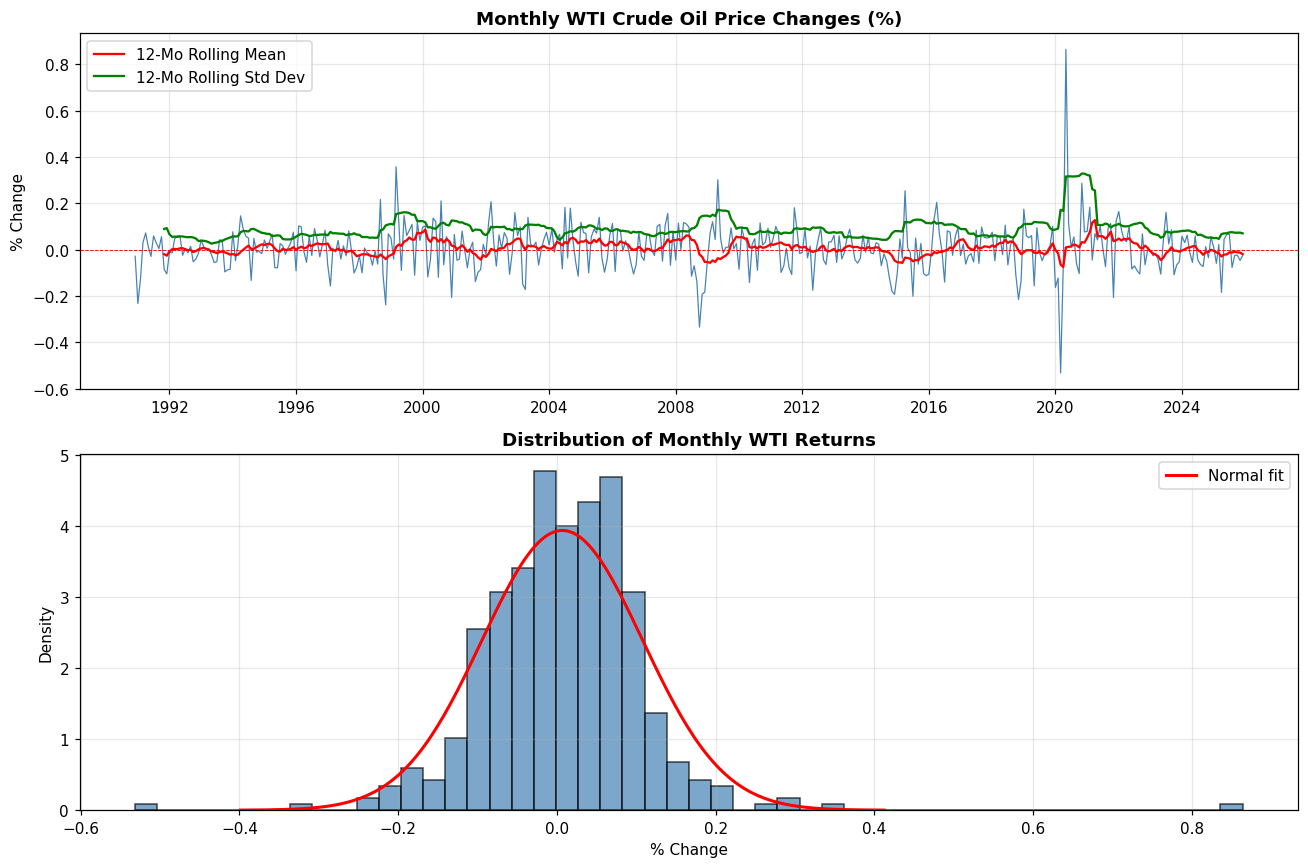

Skewness:  1.0548
Kurtosis:  16.4309  (Normal = 3.0)
Jarque-Bera: stat=3242.42, p-value=0.0000e+00


In [118]:
# ── Figure 1: WTI monthly returns time series ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Time series of WTI returns
axes[0].plot(monthly.index, monthly["wti_chg_pct"], linewidth=0.8, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.6)
axes[0].set_title("Monthly WTI Crude Oil Price Changes (%)", weight="bold")
axes[0].set_ylabel("% Change")
axes[0].grid(True, alpha=0.3)

# Rolling mean and std (12-month window)
roll_win = 12
roll_mean = monthly["wti_chg_pct"].rolling(roll_win).mean()
roll_std = monthly["wti_chg_pct"].rolling(roll_win).std()
axes[0].plot(monthly.index, roll_mean, color="red", linewidth=1.5, label=f"{roll_win}-Mo Rolling Mean")
axes[0].plot(monthly.index, roll_std, color="green", linewidth=1.5, label=f"{roll_win}-Mo Rolling Std Dev")
axes[0].legend()

# Histogram of WTI returns
axes[1].hist(monthly["wti_chg_pct"].dropna(), bins=50, color="steelblue",
             edgecolor="black", alpha=0.7, density=True)
axes[1].set_title("Distribution of Monthly WTI Returns", weight="bold")
axes[1].set_xlabel("% Change")
axes[1].set_ylabel("Density")
axes[1].grid(True, alpha=0.3)

# Overlay normal distribution for comparison
mu, sigma = monthly["wti_chg_pct"].mean(), monthly["wti_chg_pct"].std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
axes[1].plot(x, (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2),
             color="red", linewidth=2, label="Normal fit")
axes[1].legend()

plt.tight_layout()
plt.show()

# Skewness and kurtosis
from scipy.stats import jarque_bera, skew, kurtosis
wti = monthly["wti_chg_pct"].dropna()
print(f"Skewness:  {skew(wti):.4f}")
print(f"Kurtosis:  {kurtosis(wti, fisher=False):.4f}  (Normal = 3.0)")
jb_stat, jb_p = jarque_bera(wti)
print(f"Jarque-Bera: stat={jb_stat:.2f}, p-value={jb_p:.4e}")

### 2.3 Correlation Matrix
Examine pairwise correlations among all variables. High correlations among predictors may signal multicollinearity, which we will formally test via VIF.

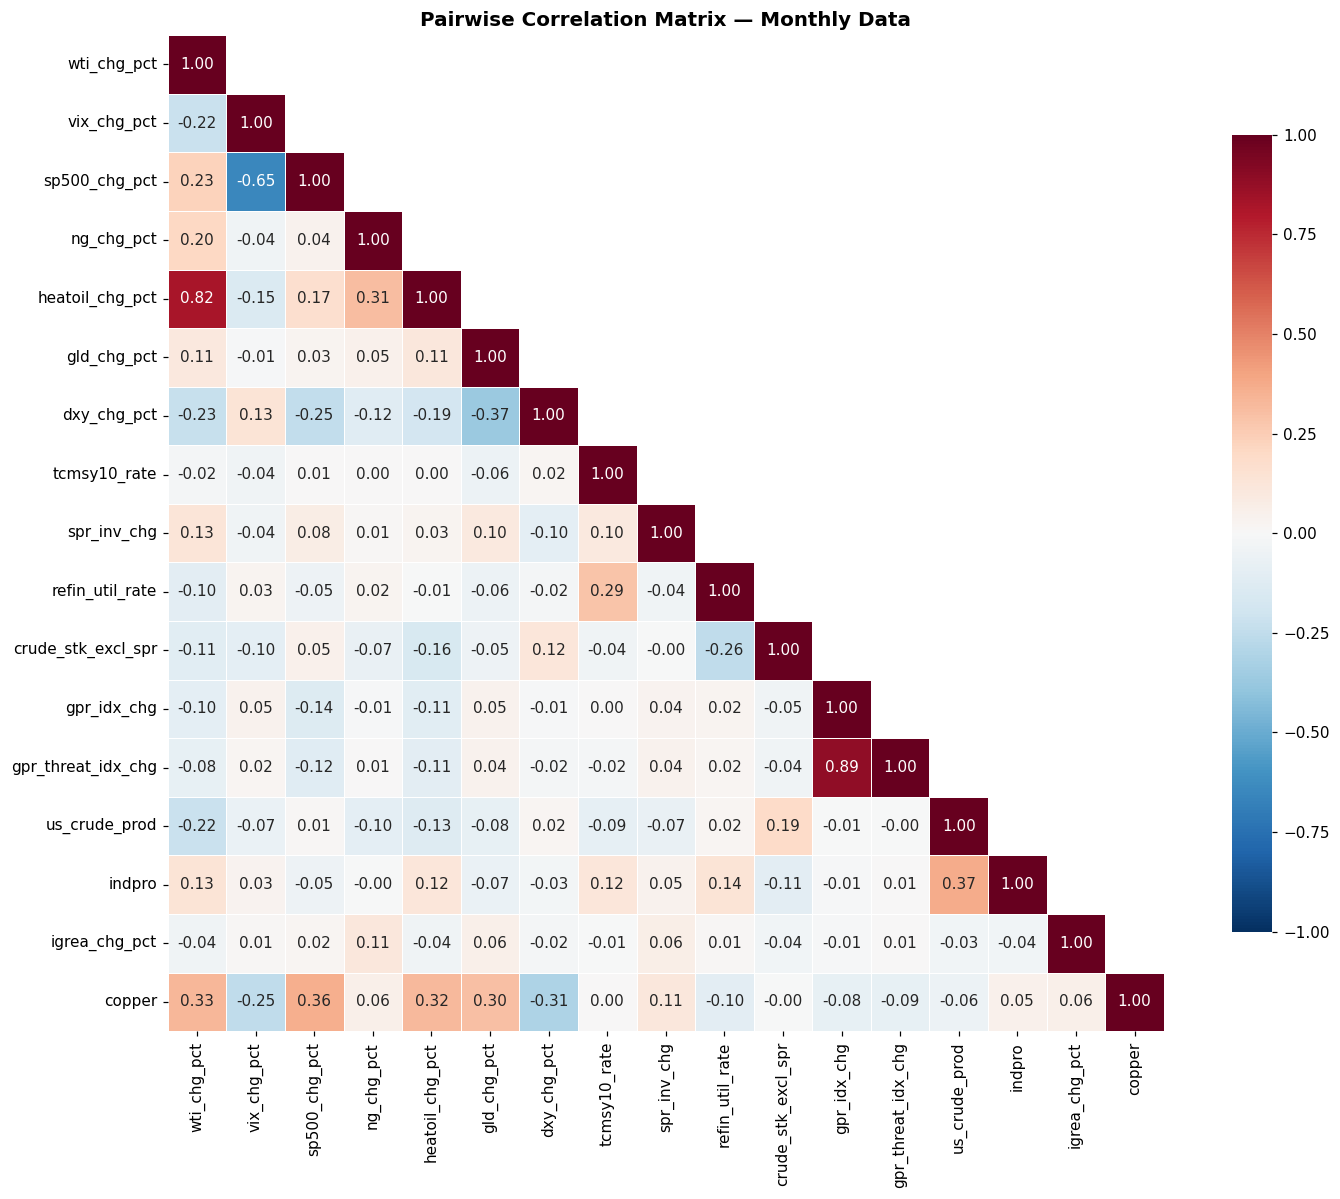

=== Correlations with WTI % Change (sorted) ===
heatoil_chg_pct       0.8243
copper                0.3303
sp500_chg_pct         0.2333
ng_chg_pct            0.2033
indpro                0.1344
spr_inv_chg           0.1276
gld_chg_pct           0.1080
tcmsy10_rate         -0.0211
igrea_chg_pct        -0.0409
gpr_threat_idx_chg   -0.0823
gpr_idx_chg          -0.0978
refin_util_rate      -0.1037
crude_stk_excl_spr   -0.1110
us_crude_prod        -0.2191
vix_chg_pct          -0.2207
dxy_chg_pct          -0.2273


In [119]:
# ── Figure 2: Correlation heatmap ───────────────────────────────────────────
corr = monthly.corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pairwise Correlation Matrix — Monthly Data", weight="bold", fontsize=13)
plt.tight_layout()
plt.show()

# Show correlations with WTI
print("=== Correlations with WTI % Change (sorted) ===")
print(corr["wti_chg_pct"].drop("wti_chg_pct").sort_values(ascending=False).round(4).to_string())

---
## 3. Stationarity Verification — Augmented Dickey-Fuller Test

Following Brooks (Ch. 7), we must verify that all series are stationary before estimating regression or ARMA-type models. Non-stationary series can produce spurious regressions with inflated R² and misleading t-statistics. The ADF test is applied to every variable; the null hypothesis is that the series contains a unit root (is non-stationary).

In [120]:
# ── ADF test on all monthly series ──────────────────────────────────────────
print("=== Augmented Dickey-Fuller Tests (Monthly) ===")
print(f"{'Variable':<22} {'ADF Stat':>10} {'p-value':>10} {'Lags':>6}  Result")
print("-" * 70)

adf_results = {}
for col in monthly.columns:
    series = monthly[col].dropna()
    if len(series) < 20:
        continue
    result = adfuller(series, autolag="AIC")
    adf_results[col] = {"stat": result[0], "pval": result[1], "lags": result[2]}
    status = "Stationary" if result[1] < 0.05 else "NON-STATIONARY"
    marker = "  ***" if result[1] >= 0.05 else ""
    print(f"{col:<22} {result[0]:>10.3f} {result[1]:>10.4f} {result[2]:>6d}  {status}{marker}")

print("\nNote: Series marked *** may require differencing or should be treated")
print("as levels (rates) rather than returns in the regression.")

=== Augmented Dickey-Fuller Tests (Monthly) ===
Variable                 ADF Stat    p-value   Lags  Result
----------------------------------------------------------------------
wti_chg_pct               -11.849     0.0000      3  Stationary
vix_chg_pct               -10.816     0.0000      5  Stationary
sp500_chg_pct             -20.863     0.0000      0  Stationary
ng_chg_pct                 -6.379     0.0000     10  Stationary
heatoil_chg_pct           -17.591     0.0000      0  Stationary
gld_chg_pct               -22.161     0.0000      0  Stationary
dxy_chg_pct               -18.996     0.0000      0  Stationary
tcmsy10_rate               -2.264     0.1839      2  NON-STATIONARY  ***
spr_inv_chg                -4.510     0.0002      5  Stationary
refin_util_rate            -3.301     0.0148     13  Stationary
crude_stk_excl_spr         -5.129     0.0000     13  Stationary
gpr_idx_chg               -16.967     0.0000      1  Stationary
gpr_threat_idx_chg        -19.190     0.0000

---
## 4. OLS Multiple Regression (Monthly)

### 4.1 Baseline OLS
We regress WTI monthly % changes on **lagged (t-1) predictors** — this is a true predictive model where we use last period's information to predict this period's WTI return. Per Brooks (Ch. 4–5), this also ensures Cov(xₜ, εₜ) = 0 (CLRM Assumption 4), since the regressors are predetermined.

Any variables found non-stationary above will be first-differenced before inclusion.

In [121]:
# ── Prepare regression data: difference non-stationary series, then lag ──────
reg_monthly = monthly.copy()

# Difference non-stationary level variables (rates / levels that failed ADF)
level_vars = ["tcmsy10_rate", "refin_util_rate", "crude_stk_excl_spr", "us_crude_prod"]
for var in level_vars:
    if var in adf_results and adf_results[var]["pval"] >= 0.05:
        reg_monthly[var + "_diff"] = reg_monthly[var].diff()
        reg_monthly = reg_monthly.drop(columns=[var])
        print(f"Differenced {var} -> {var}_diff (was non-stationary)")
    else:
        print(f"Kept {var} as-is (stationary, p={adf_results.get(var, {}).get('pval', 'N/A')})")

# Separate target (current period) from predictors (lagged one period)
target = "wti_chg_pct"
predictor_cols = [c for c in reg_monthly.columns if c != target]

# Create lagged predictors: X(t-1) predicts Y(t)
lagged = reg_monthly[predictor_cols].shift(1)
lagged.columns = [c + "_lag1" for c in lagged.columns]

# Combine current WTI with lagged predictors
reg_data = pd.concat([reg_monthly[[target]], lagged], axis=1).dropna()
features = [c for c in reg_data.columns if c != target]

print(f"\nRegression sample: {len(reg_data)} observations, {len(features)} lagged predictors")
print(f"Using X(t-1) to predict WTI(t) — a true predictive specification")

Differenced tcmsy10_rate -> tcmsy10_rate_diff (was non-stationary)
Kept refin_util_rate as-is (stationary, p=0.014847065732468948)
Kept crude_stk_excl_spr as-is (stationary, p=1.2262956730345162e-05)
Kept us_crude_prod as-is (stationary, p=4.4281860975165965e-30)

Regression sample: 419 observations, 16 lagged predictors
Using X(t-1) to predict WTI(t) — a true predictive specification


In [122]:
# ── OLS Regression ──────────────────────────────────────────────────────────
X = sm.add_constant(reg_data[features])
y = reg_data[target]

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            wti_chg_pct   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     2.786
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           0.000280
Time:                        17:24:23   Log-Likelihood:                 388.87
No. Observations:                 419   AIC:                            -743.7
Df Residuals:                     402   BIC:                            -675.1
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

### 4.2 Variance Inflation Factors (VIF)
Per Brooks (Ch. 5), multicollinearity inflates standard errors and can make individually insignificant coefficients appear jointly significant. VIF > 10 is a common rule-of-thumb for problematic multicollinearity.

In [123]:
# ── VIF calculation ─────────────────────────────────────────────────────────
X_no_const = reg_data[features].dropna()
vif_data = pd.DataFrame({
    "Variable": X_no_const.columns,
    "VIF": [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
}).sort_values("VIF", ascending=False)
print("=== Variance Inflation Factors ===")
print(vif_data.to_string(index=False))
high_vif = vif_data[vif_data["VIF"] > 10]
if len(high_vif) > 0:
    print(f"\nWarning: {len(high_vif)} variable(s) with VIF > 10 — consider removal.")
else:
    print("\nNo severe multicollinearity detected (all VIF < 10).")

=== Variance Inflation Factors ===
               Variable      VIF
gpr_threat_idx_chg_lag1 4.727171
       gpr_idx_chg_lag1 4.700769
     sp500_chg_pct_lag1 2.052032
       vix_chg_pct_lag1 1.798790
            copper_lag1 1.521200
   heatoil_chg_pct_lag1 1.402932
       dxy_chg_pct_lag1 1.370661
       gld_chg_pct_lag1 1.342870
     us_crude_prod_lag1 1.316174
            indpro_lag1 1.304170
 tcmsy10_rate_diff_lag1 1.227844
   refin_util_rate_lag1 1.207813
        ng_chg_pct_lag1 1.162988
crude_stk_excl_spr_lag1 1.134592
       spr_inv_chg_lag1 1.053532
     igrea_chg_pct_lag1 1.039240

No severe multicollinearity detected (all VIF < 10).


### 4.3 OLS Residual Diagnostics
Per Brooks (Ch. 5, 8), OLS assumes i.i.d. errors. We test for:
1. **Autocorrelation** — Durbin-Watson statistic and Breusch-Godfrey LM test
2. **Heteroskedasticity** — Breusch-Pagan test and White's test
3. **ARCH effects** — Engle's ARCH-LM test (motivates GARCH if significant)
4. **Normality** — Jarque-Bera on residuals

In [124]:
# ── OLS Residual Diagnostic Tests ───────────────────────────────────────────
resids = ols_model.resid

print("=" * 60)
print("OLS RESIDUAL DIAGNOSTIC TESTS")
print("=" * 60)

# 1. Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(resids)
print(f"\n1. Durbin-Watson: {dw:.4f}  (≈2 = no autocorrelation)")

# 2. Breusch-Godfrey serial correlation LM test
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
bg_stat, bg_p, _, _ = acorr_breusch_godfrey(ols_model, nlags=4)
print(f"2. Breusch-Godfrey (4 lags): stat={bg_stat:.3f}, p={bg_p:.4f}")
print(f"   {'Reject H0: serial correlation detected' if bg_p < 0.05 else 'Fail to reject H0: no serial correlation'}")

# 3. Breusch-Pagan heteroskedasticity test
bp_stat, bp_p, _, _ = het_breuschpagan(resids, X)
print(f"3. Breusch-Pagan: stat={bp_stat:.3f}, p={bp_p:.4f}")
print(f"   {'Reject H0: heteroskedasticity detected' if bp_p < 0.05 else 'Fail to reject H0: homoskedastic'}")

# 4. ARCH-LM test (Engle, 1982)
arch_stat, arch_p, _, _ = het_arch(resids, nlags=4)
print(f"4. ARCH-LM (4 lags): stat={arch_stat:.3f}, p={arch_p:.4f}")
print(f"   {'Reject H0: ARCH effects detected → GARCH warranted' if arch_p < 0.05 else 'Fail to reject H0: no ARCH effects'}")

# 5. Jarque-Bera on residuals
jb_stat, jb_p = jarque_bera(resids)
print(f"5. Jarque-Bera (residuals): stat={jb_stat:.2f}, p={jb_p:.4e}")
print(f"   {'Reject H0: residuals non-normal' if jb_p < 0.05 else 'Fail to reject H0: residuals normal'}")

# 6. Ljung-Box on residuals
lb = acorr_ljungbox(resids, lags=[5, 10, 15], return_df=True)
print(f"\n6. Ljung-Box Q-test on residuals:")
print(lb.to_string())

OLS RESIDUAL DIAGNOSTIC TESTS

1. Durbin-Watson: 2.0026  (≈2 = no autocorrelation)
2. Breusch-Godfrey (4 lags): stat=6.455, p=0.1676
   Fail to reject H0: no serial correlation
3. Breusch-Pagan: stat=136.004, p=0.0000
   Reject H0: heteroskedasticity detected
4. ARCH-LM (4 lags): stat=47.642, p=0.0000
   Reject H0: ARCH effects detected → GARCH warranted
5. Jarque-Bera (residuals): stat=296.59, p=3.9429e-65
   Reject H0: residuals non-normal

6. Ljung-Box Q-test on residuals:
      lb_stat  lb_pvalue
5    5.812859   0.324857
10  14.458489   0.153087
15  24.508451   0.056947


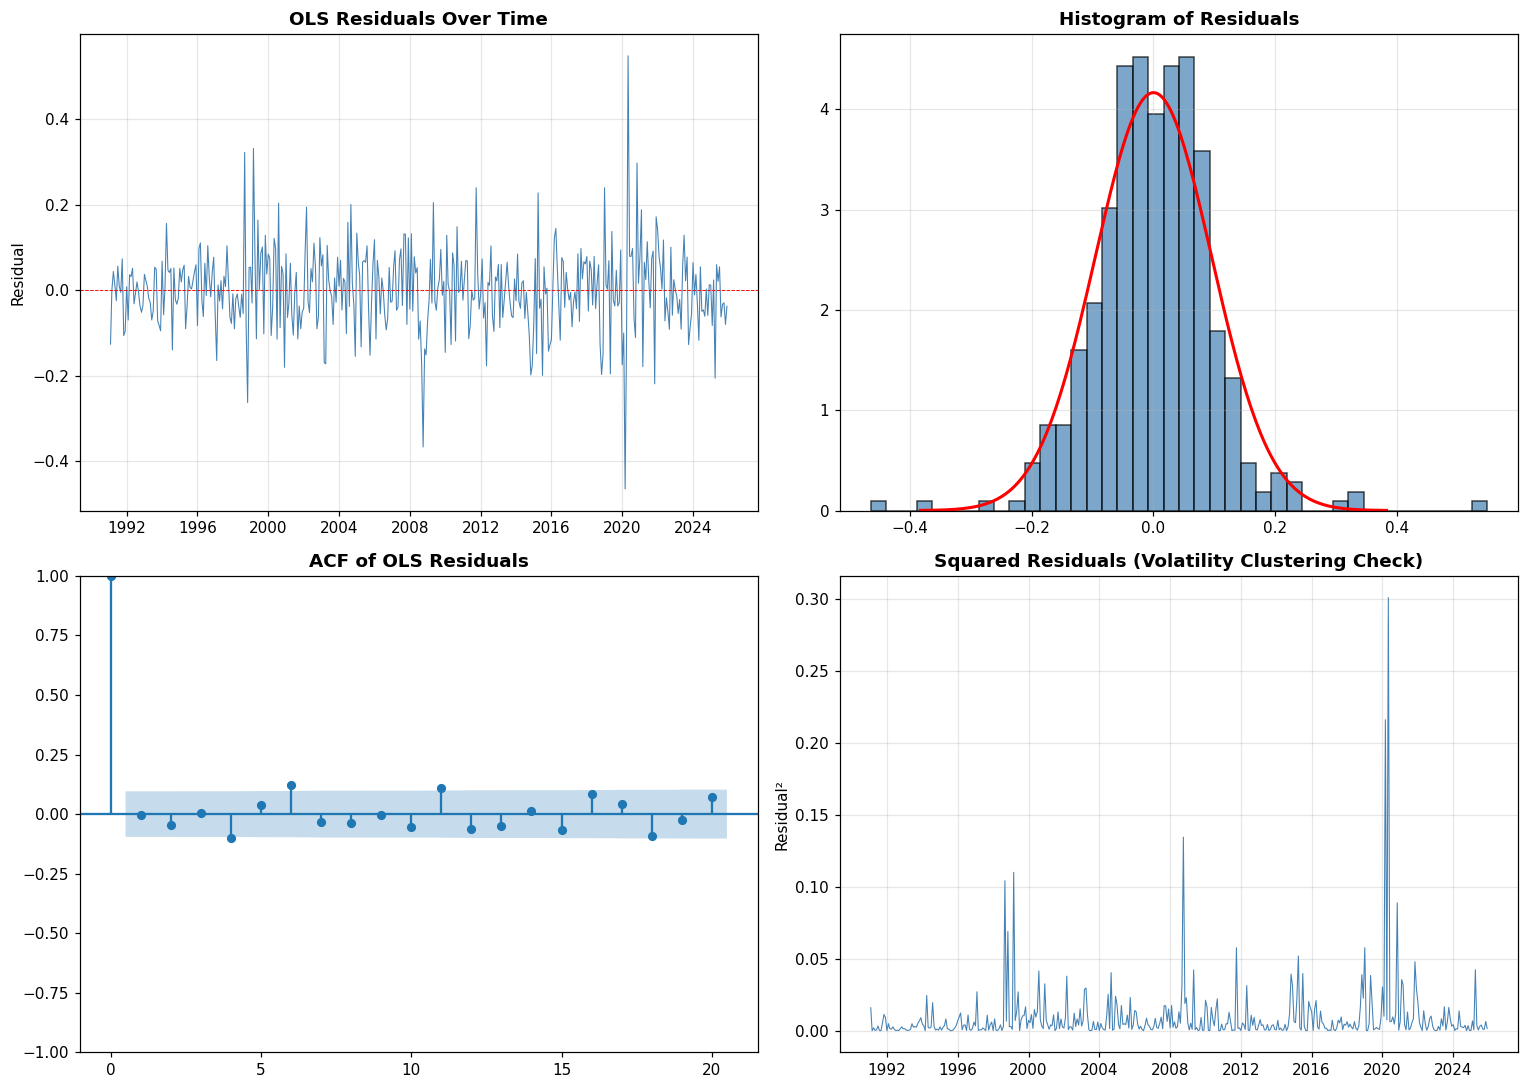

In [125]:
# ── Figure 3: OLS Residual Plots ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals over time
axes[0, 0].plot(reg_data.index, resids, linewidth=0.7, color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=0.6)
axes[0, 0].set_title("OLS Residuals Over Time", weight="bold")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].grid(True, alpha=0.3)

# Histogram of residuals
axes[0, 1].hist(resids, bins=40, color="steelblue", edgecolor="black", alpha=0.7, density=True)
mu_r, sig_r = resids.mean(), resids.std()
xr = np.linspace(mu_r - 4*sig_r, mu_r + 4*sig_r, 200)
axes[0, 1].plot(xr, (1/(sig_r*np.sqrt(2*np.pi))) * np.exp(-0.5*((xr-mu_r)/sig_r)**2),
                color="red", linewidth=2)
axes[0, 1].set_title("Histogram of Residuals", weight="bold")
axes[0, 1].grid(True, alpha=0.3)

# ACF of residuals
plot_acf(resids, lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF of OLS Residuals", weight="bold")

# Squared residuals (visual check for ARCH effects)
axes[1, 1].plot(reg_data.index, resids**2, linewidth=0.7, color="steelblue")
axes[1, 1].set_title("Squared Residuals (Volatility Clustering Check)", weight="bold")
axes[1, 1].set_ylabel("Residual²")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 Reduced OLS — Retain Only Significant Predictors
Following the general-to-specific approach (Brooks Ch. 5), we re-estimate the model dropping insignificant variables to improve parsimony and potentially reduce multicollinearity, while retaining economic interpretability.

In [126]:
# ── Reduced model: keep variables significant at 10% level ──────────────────
sig_vars = [v for v in features if ols_model.pvalues.get(v, 1.0) < 0.10]
print(f"Significant predictors (p < 0.10): {sig_vars}\n")

X_reduced = sm.add_constant(reg_data[sig_vars])
ols_reduced = sm.OLS(y, X_reduced).fit()
print(ols_reduced.summary())

# Compare AIC/BIC
print(f"\nModel comparison:")
print(f"  Full model:    AIC={ols_model.aic:.2f}, BIC={ols_model.bic:.2f}, Adj-R²={ols_model.rsquared_adj:.4f}")
print(f"  Reduced model: AIC={ols_reduced.aic:.2f}, BIC={ols_reduced.bic:.2f}, Adj-R²={ols_reduced.rsquared_adj:.4f}")

# ── Newey-West HAC standard errors (robust to heteroskedasticity + autocorrelation)
# Breusch-Pagan detected heteroskedasticity, so HAC ensures valid inference
ols_hac = sm.OLS(y, X_reduced).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print("\n" + "=" * 60)
print("REDUCED OLS WITH NEWEY-WEST (HAC) STANDARD ERRORS")
print("=" * 60)
print(ols_hac.summary())

print("\n=== OLS vs HAC p-value comparison ===")
print(f"{'Variable':<22} {'OLS p':>10} {'HAC p':>10}  Δ Inference?")
print("-" * 55)
for v in sig_vars:
    ols_p = ols_reduced.pvalues[v]
    hac_p = ols_hac.pvalues[v]
    flag = "  *" if (ols_p < 0.05) != (hac_p < 0.05) else ""
    print(f"{v:<22} {ols_p:>10.4f} {hac_p:>10.4f}{flag}")

Significant predictors (p < 0.10): ['indpro_lag1', 'tcmsy10_rate_diff_lag1']

                            OLS Regression Results                            
Dep. Variable:            wti_chg_pct   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     12.63
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           4.71e-06
Time:                        17:24:23   Log-Likelihood:                 379.20
No. Observations:                 419   AIC:                            -752.4
Df Residuals:                     416   BIC:                            -740.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

---
## 5. Autocorrelation Structure — ACF and PACF Analysis

Per Brooks (Ch. 6), the ACF and PACF of the dependent variable and OLS residuals guide the choice of AR/MA lag order for the mean equation. We examine both the raw WTI returns and the OLS residuals.

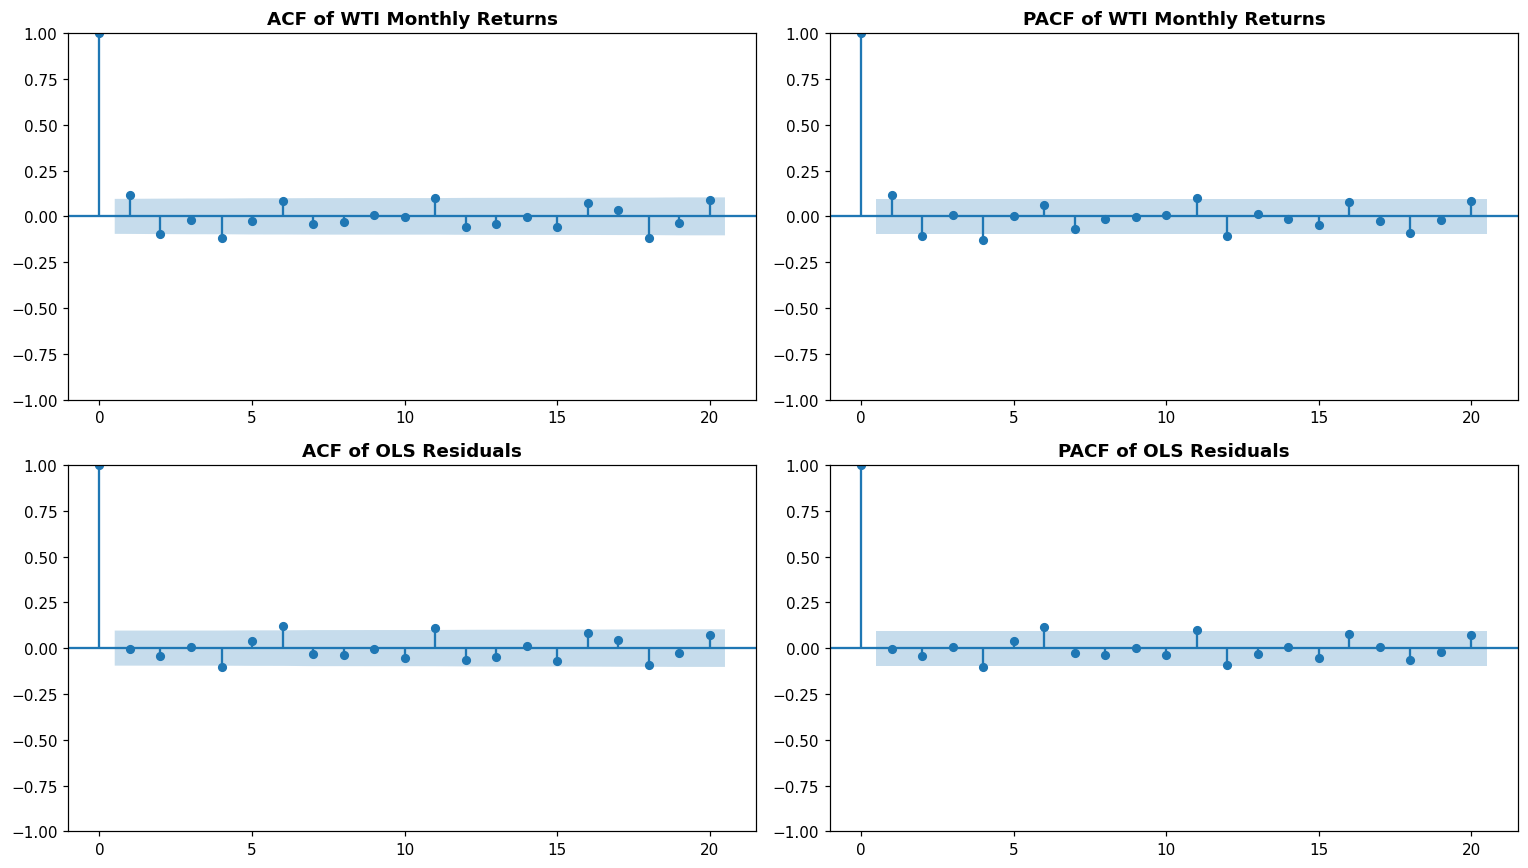

=== AIC/BIC for AR(p) on OLS residuals ===
  AR(0): AIC=-773.74, BIC=-765.66
  AR(1): AIC=-771.74, BIC=-759.63
  AR(2): AIC=-770.57, BIC=-754.42
  AR(3): AIC=-768.58, BIC=-748.39
  AR(4): AIC=-771.10, BIC=-746.88


In [127]:
# ── Figure 4: ACF / PACF of WTI returns and OLS residuals ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(monthly["wti_chg_pct"].dropna(), lags=20, ax=axes[0, 0])
axes[0, 0].set_title("ACF of WTI Monthly Returns", weight="bold")

plot_pacf(monthly["wti_chg_pct"].dropna(), lags=20, ax=axes[0, 1])
axes[0, 1].set_title("PACF of WTI Monthly Returns", weight="bold")

plot_acf(resids, lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF of OLS Residuals", weight="bold")

plot_pacf(resids, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("PACF of OLS Residuals", weight="bold")

plt.tight_layout()
plt.show()

# Information criteria to pick AR order for residuals
print("=== AIC/BIC for AR(p) on OLS residuals ===")
for p in range(0, 5):
    try:
        ar_model = sm.tsa.ARIMA(resids, order=(p, 0, 0)).fit()
        print(f"  AR({p}): AIC={ar_model.aic:.2f}, BIC={ar_model.bic:.2f}")
    except Exception:
        pass

---
## 6. GARCH Volatility Models — Monthly

Per Brooks (Ch. 8–9), when ARCH effects or heteroskedasticity are present in the OLS residuals, coefficient standard errors from OLS are unreliable. A GARCH variance specification corrects for time-varying volatility, yielding consistent and efficient estimates.

We compare three volatility specifications:
- **GARCH(1,1)** — symmetric baseline (Bollerslev, 1986)
- **EGARCH(1,1)** — exponential GARCH, captures asymmetry via log-variance (Nelson, 1991)
- **GJR-GARCH(1,1,1)** — threshold GARCH, explicit leverage term γ for negative shocks (Glosten et al., 1993)

All use an ARX(1) mean equation with significant regressors and Student-t innovations to accommodate fat tails. The best model is selected by AIC/BIC and post-estimation ARCH-LM diagnostics.

In [128]:
# ── Compare GARCH, EGARCH, GJR-GARCH on monthly data ───────────────────────
# Scale returns to percentage points for numerical stability (arch library preference)
y_pct = reg_data[target] * 100
exog = reg_data[sig_vars] * 100

garch_specs = {
    "GARCH(1,1)":     dict(vol="GARCH", p=1, o=0, q=1),
    "EGARCH(1,1)":    dict(vol="EGARCH", p=1, o=0, q=1),
    "GJR-GARCH(1,1)": dict(vol="GARCH", p=1, o=1, q=1),
}

garch_results = {}
print("=" * 75)
print("GARCH MODEL COMPARISON — MONTHLY (with lagged regressors)")
print("=" * 75)

for name, spec_kw in garch_specs.items():
    # AR(1) in mean captures autocorrelation in WTI itself;
    # exog variables are already lagged (t-1) from the regression prep
    spec = arch_model(y_pct, x=exog, mean="ARX", lags=1, dist="t", **spec_kw)
    fit = spec.fit(disp="off")
    std_r = (fit.resid / fit.conditional_volatility).dropna()
    arch_lm = het_arch(std_r, nlags=4)
    lb_sq = acorr_ljungbox(std_r**2, lags=[10], return_df=True)

    garch_results[name] = fit
    print(f"\n{'─'*30} {name} {'─'*30}")
    print(f"  Log-Lik: {fit.loglikelihood:.2f}  AIC: {fit.aic:.2f}  BIC: {fit.bic:.2f}")
    print(f"  Post-GARCH ARCH-LM(4):  stat={arch_lm[0]:.3f}, p={arch_lm[1]:.4f}  "
          f"{'✓ adequate' if arch_lm[1] > 0.05 else '✗ remaining ARCH effects'}")
    print(f"  Ljung-Box sq(10):       p={lb_sq['lb_pvalue'].values[0]:.4f}")
    # Volatility params
    for pname in fit.params.index:
        if any(k in pname for k in ["omega", "alpha", "beta", "gamma", "nu"]):
            print(f"  {pname:12s}: {fit.params[pname]:>10.6f}  (p={fit.pvalues[pname]:.4f})")

# Select best by AIC
best_name = min(garch_results, key=lambda k: garch_results[k].aic)
garch_fit = garch_results[best_name]
print(f"\n{'='*75}")
print(f"Selected model: {best_name} (lowest AIC = {garch_fit.aic:.2f})")
print(f"{'='*75}")
print(garch_fit.summary())

GARCH MODEL COMPARISON — MONTHLY (with lagged regressors)

────────────────────────────── GARCH(1,1) ──────────────────────────────
  Log-Lik: -1499.96  AIC: 3015.92  BIC: 3048.20
  Post-GARCH ARCH-LM(4):  stat=30.482, p=0.0000  ✗ remaining ARCH effects
  Ljung-Box sq(10):       p=0.0005
  omega       :  10.834723  (p=0.0993)
  alpha[1]    :   0.212664  (p=0.0815)
  beta[1]     :   0.676260  (p=0.0000)
  nu          :   8.727055  (p=0.0074)

────────────────────────────── EGARCH(1,1) ──────────────────────────────
  Log-Lik: -1499.25  AIC: 3014.51  BIC: 3046.79
  Post-GARCH ARCH-LM(4):  stat=48.867, p=0.0000  ✗ remaining ARCH effects
  Ljung-Box sq(10):       p=0.0000
  omega       :   0.542704  (p=0.1044)
  alpha[1]    :   0.354889  (p=0.0939)
  beta[1]     :   0.877691  (p=0.0000)
  nu          :   7.742275  (p=0.0024)

────────────────────────────── GJR-GARCH(1,1) ──────────────────────────────
  Log-Lik: -1497.53  AIC: 3013.07  BIC: 3049.39
  Post-GARCH ARCH-LM(4):  stat=21.017, p=

### 6.1 GARCH Residual Diagnostics
Per Brooks (Ch. 9), a well-specified GARCH model should produce standardized residuals that are approximately white noise — no remaining autocorrelation in either the standardized residuals or their squares.

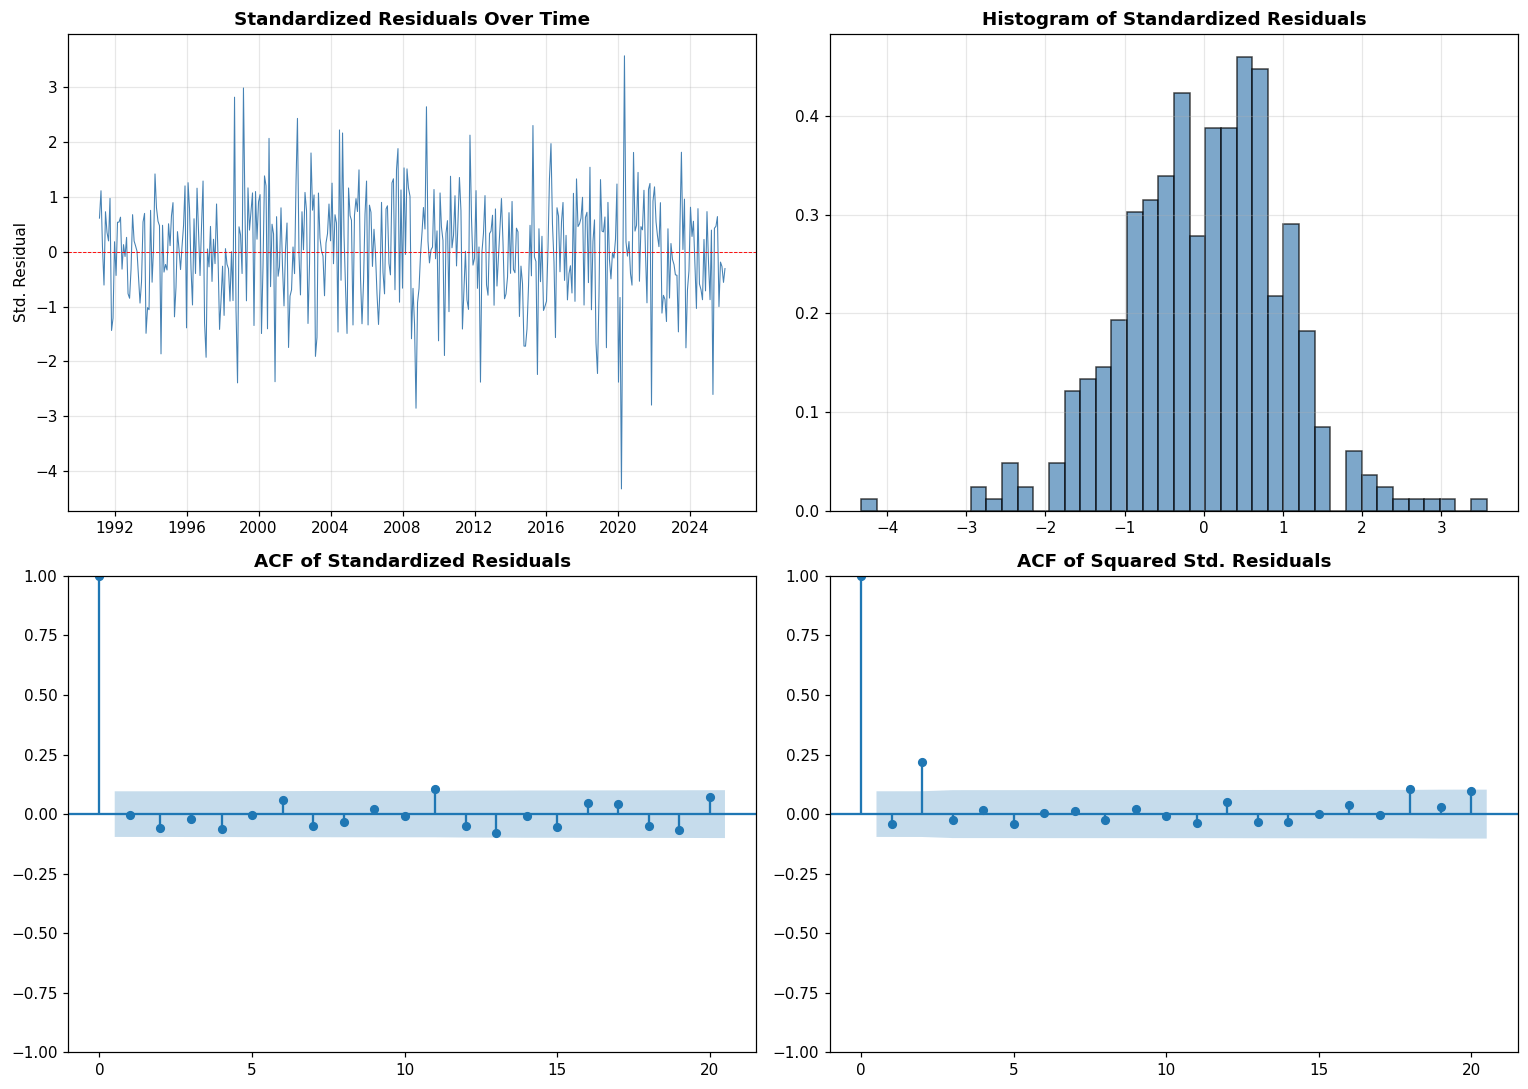

=== Ljung-Box Tests on GARCH Standardized Residuals ===

Standardized Residuals:
      lb_stat  lb_pvalue
5    3.493133   0.624427
10   6.632236   0.759648
15  16.803897   0.330722

Squared Standardized Residuals (ARCH effects check):
      lb_stat  lb_pvalue
5   22.350595   0.000449
10  22.903075   0.011110
15  25.590165   0.042558

ARCH-LM on std. residuals: stat=21.017, p=0.0003
Remaining ARCH effects detected


In [129]:
# ── GARCH standardized residual diagnostics ─────────────────────────────────
std_resid = garch_fit.resid / garch_fit.conditional_volatility
std_resid_clean = std_resid.dropna()

# Figure 5: Standardized residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time series
axes[0, 0].plot(std_resid_clean.index, std_resid_clean, linewidth=0.7, color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=0.6)
axes[0, 0].set_title("Standardized Residuals Over Time", weight="bold")
axes[0, 0].set_ylabel("Std. Residual")
axes[0, 0].grid(True, alpha=0.3)

# Histogram
axes[0, 1].hist(std_resid_clean, bins=40, color="steelblue", edgecolor="black",
                alpha=0.7, density=True)
axes[0, 1].set_title("Histogram of Standardized Residuals", weight="bold")
axes[0, 1].grid(True, alpha=0.3)

# ACF of standardized residuals
plot_acf(std_resid_clean, lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF of Standardized Residuals", weight="bold")

# ACF of squared standardized residuals (check for remaining ARCH effects)
plot_acf(std_resid_clean**2, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF of Squared Std. Residuals", weight="bold")

plt.tight_layout()
plt.show()

# Ljung-Box on standardized residuals and their squares
print("=== Ljung-Box Tests on GARCH Standardized Residuals ===")
lb_resid = acorr_ljungbox(std_resid_clean, lags=[5, 10, 15], return_df=True)
print("\nStandardized Residuals:")
print(lb_resid.to_string())

lb_sq = acorr_ljungbox(std_resid_clean**2, lags=[5, 10, 15], return_df=True)
print("\nSquared Standardized Residuals (ARCH effects check):")
print(lb_sq.to_string())

# ARCH-LM on standardized residuals
arch_lm_post = het_arch(std_resid_clean, nlags=4)
print(f"\nARCH-LM on std. residuals: stat={arch_lm_post[0]:.3f}, p={arch_lm_post[1]:.4f}")
print(f"{'Remaining ARCH effects detected' if arch_lm_post[1] < 0.05 else 'No remaining ARCH effects — model adequate'}")

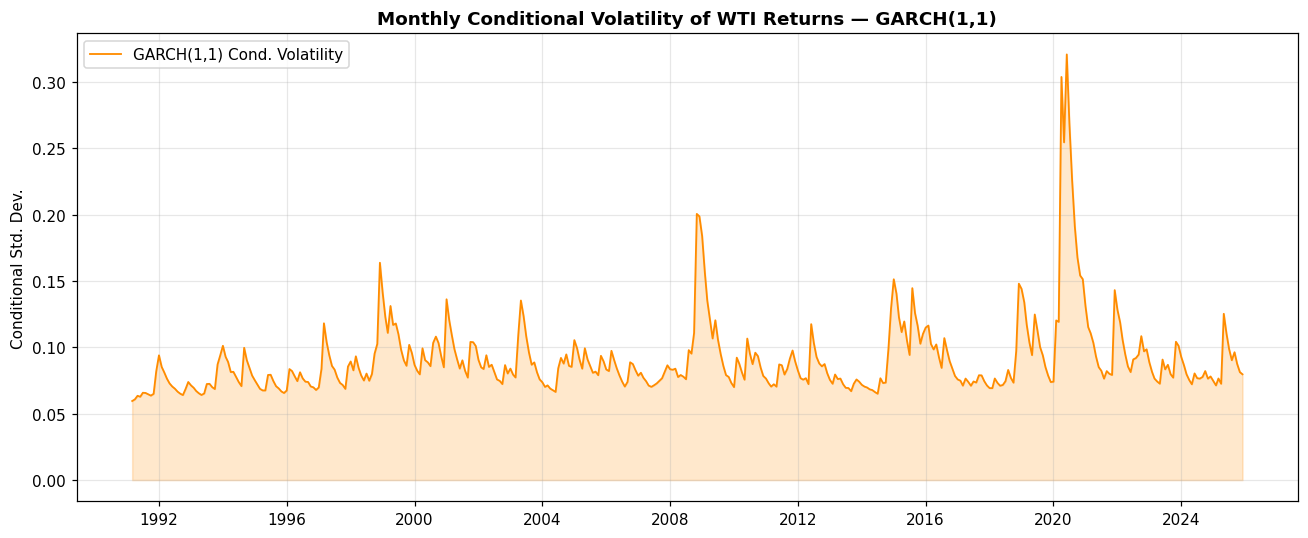

Volatility persistence (α₁ + β₁): 0.7581
Half-life of volatility shocks: 2.5 periods


In [130]:
# ── Figure 6: Conditional Volatility from GARCH ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
cond_vol = garch_fit.conditional_volatility / 100  # scale back to decimal
ax.plot(cond_vol.index, cond_vol, color="darkorange", linewidth=1.2, label="GARCH(1,1) Cond. Volatility")
ax.fill_between(cond_vol.index, 0, cond_vol, alpha=0.2, color="darkorange")
ax.set_title("Monthly Conditional Volatility of WTI Returns — GARCH(1,1)", weight="bold")
ax.set_ylabel("Conditional Std. Dev.")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Persistence
alpha = garch_fit.params.get("alpha[1]", 0)
beta = garch_fit.params.get("beta[1]", 0)
print(f"Volatility persistence (α₁ + β₁): {alpha + beta:.4f}")
print(f"Half-life of volatility shocks: {np.log(2) / -np.log(alpha + beta):.1f} periods" if alpha + beta < 1 else "Non-stationary variance")

---
## 7. Weekly Analysis

We now repeat the full analysis pipeline — OLS, diagnostics, and GARCH — on weekly data constructed from daily closing prices. This allows us to compare whether higher-frequency data produces stronger or weaker predictive relationships, and whether the same factors that matter monthly also matter weekly.

Note: Monthly-only variables (GPR, INDPRO, IGREA, US crude production) are excluded from the weekly specification.

In [131]:
# ── Weekly: Descriptive stats and missing data ──────────────────────────────
print("=== Weekly Descriptive Statistics ===\n")
print(weekly.describe().round(4).to_string())
print(f"\n=== Missing values ===\n{weekly.isnull().sum()}")
print(f"\nTotal obs: {len(weekly)}, Complete cases: {weekly.dropna().shape[0]}")

=== Weekly Descriptive Statistics ===

       copper_chg_pct  dxy_chg_pct  gld_chg_pct  heatoil_chg_pct  ng_chg_pct  ovx_chg_pct  sp500_chg_pct  wti_chg_pct  tcmsy10_rate  tcmsy10_chg_pct  refin_util_rate  spr_inv_chg  crude_stk_excl_spr_chg
count       1831.0000    1831.0000    1831.0000        1831.0000   1831.0000     973.0000      1831.0000    1831.0000     1831.0000        1831.0000        1831.0000    1831.0000               1831.0000
mean           0.0015       0.0002       0.0016           0.0015      0.0031       0.0067         0.0019       0.0017        4.1275           0.0006          89.6949      -0.0002                  0.0002
std            0.0340       0.0110       0.0222           0.0451      0.0760       0.1236         0.0231       0.0509        1.8289           0.0434           4.9241       0.0021                  0.0127
min           -0.2262      -0.0433      -0.0964          -0.2522     -0.3475      -0.4242        -0.1820      -0.2946        0.5330          -0.3353 

In [132]:
# ── Weekly: ADF Tests ───────────────────────────────────────────────────────
print("=== Augmented Dickey-Fuller Tests (Weekly) ===")
print(f"{'Variable':<24} {'ADF Stat':>10} {'p-value':>10} {'Lags':>6}  Result")
print("-" * 72)

w_adf = {}
for col in weekly.columns:
    series = weekly[col].dropna()
    if len(series) < 20:
        continue
    result = adfuller(series, autolag="AIC")
    w_adf[col] = {"stat": result[0], "pval": result[1]}
    status = "Stationary" if result[1] < 0.05 else "NON-STATIONARY ***"
    print(f"{col:<24} {result[0]:>10.3f} {result[1]:>10.4f} {result[2]:>6d}  {status}")

=== Augmented Dickey-Fuller Tests (Weekly) ===
Variable                   ADF Stat    p-value   Lags  Result
------------------------------------------------------------------------
copper_chg_pct               -8.714     0.0000     19  Stationary
dxy_chg_pct                 -43.732     0.0000      0  Stationary
gld_chg_pct                 -43.916     0.0000      0  Stationary
heatoil_chg_pct             -14.244     0.0000      7  Stationary
ng_chg_pct                  -15.170     0.0000      8  Stationary
ovx_chg_pct                  -9.387     0.0000     17  Stationary
sp500_chg_pct               -17.482     0.0000      6  Stationary
wti_chg_pct                 -10.980     0.0000     18  Stationary
tcmsy10_rate                 -2.324     0.1644      5  NON-STATIONARY ***
tcmsy10_chg_pct              -8.451     0.0000     25  Stationary
refin_util_rate              -8.036     0.0000      2  Stationary
spr_inv_chg                  -4.407     0.0003     22  Stationary
crude_stk_excl_spr

In [133]:
# ── Weekly: Prepare regression data with lagged predictors ──────────────────
reg_weekly = weekly.copy()

# Difference non-stationary level/rate variables if ADF fails
w_level_vars = ["tcmsy10_rate", "refin_util_rate"]
for var in w_level_vars:
    if var in reg_weekly.columns and var in w_adf and w_adf[var]["pval"] >= 0.05:
        reg_weekly[var + "_diff"] = reg_weekly[var].diff()
        reg_weekly = reg_weekly.drop(columns=[var])
        print(f"Differenced {var}")
    elif var in reg_weekly.columns and var in w_adf:
        print(f"Kept {var} as-is (stationary, p={w_adf[var]['pval']:.4f})")

# If we have both tcmsy10_chg_pct and tcmsy10_rate, drop the level
if "tcmsy10_chg_pct" in reg_weekly.columns and "tcmsy10_rate" in reg_weekly.columns:
    reg_weekly = reg_weekly.drop(columns=["tcmsy10_rate"])
    print("Dropped tcmsy10_rate (using tcmsy10_chg_pct instead)")

w_target = "wti_chg_pct"
w_predictor_cols = [c for c in reg_weekly.columns if c != w_target]

# Create lagged predictors: X(t-1) predicts WTI(t)
w_lagged = reg_weekly[w_predictor_cols].shift(1)
w_lagged.columns = [c + "_lag1" for c in w_lagged.columns]

w_reg_data = pd.concat([reg_weekly[[w_target]], w_lagged], axis=1).dropna()
w_features = [c for c in w_reg_data.columns if c != w_target]

print(f"\nWeekly regression sample: {len(w_reg_data)} obs, {len(w_features)} lagged predictors")
print(f"Using X(t-1) to predict WTI(t)")

# ── Weekly OLS ──────────────────────────────────────────────────────────────
w_X = sm.add_constant(w_reg_data[w_features])
w_y = w_reg_data[w_target]
w_ols = sm.OLS(w_y, w_X).fit()
print(w_ols.summary())

Differenced tcmsy10_rate
Kept refin_util_rate as-is (stationary, p=0.0000)

Weekly regression sample: 972 obs, 12 lagged predictors
Using X(t-1) to predict WTI(t)
                            OLS Regression Results                            
Dep. Variable:            wti_chg_pct   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     3.192
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           0.000169
Time:                        17:24:24   Log-Likelihood:                 1478.0
No. Observations:                 972   AIC:                            -2930.
Df Residuals:                     959   BIC:                            -2867.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                  coef    std e

WEEKLY OLS RESIDUAL DIAGNOSTIC TESTS

1. Durbin-Watson: 1.9696
2. Breusch-Godfrey (4 lags): stat=6.125, p=0.1900
   No serial correlation
3. Breusch-Pagan: stat=53.896, p=0.0000
   Heteroskedasticity detected
4. ARCH-LM (4 lags): stat=247.778, p=0.0000
   ARCH effects detected → GARCH warranted
5. Jarque-Bera: stat=887.97, p=1.5110e-193


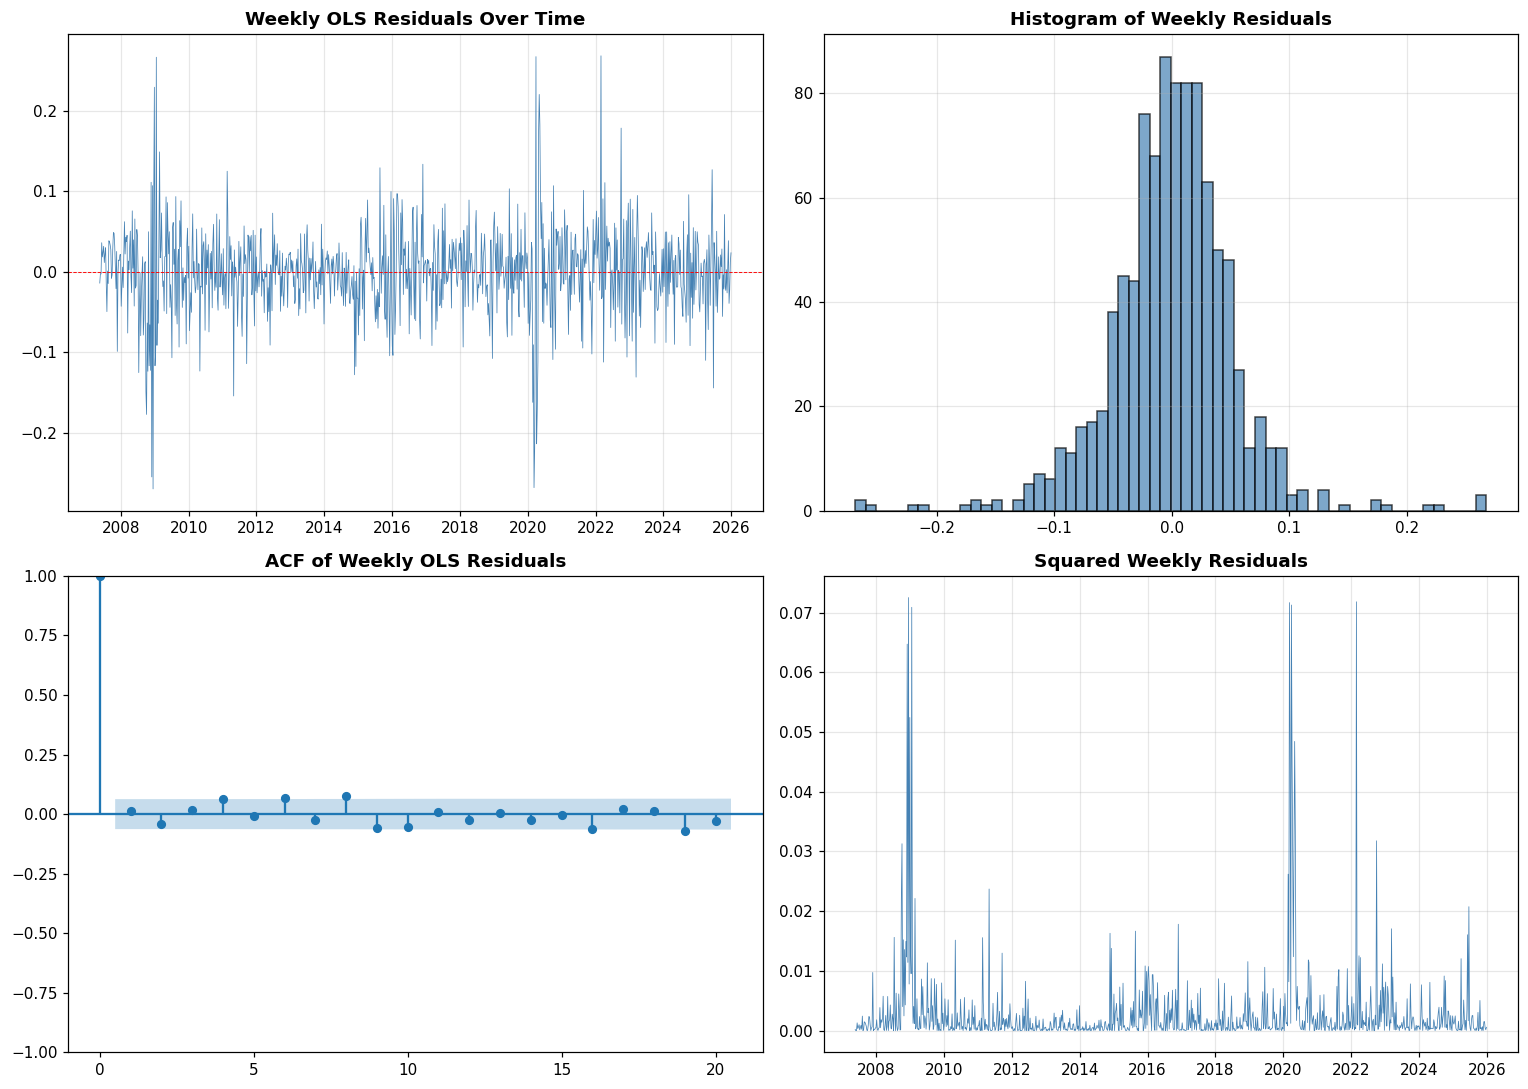

In [134]:
# ── Weekly: OLS Diagnostics ─────────────────────────────────────────────────
w_resids = w_ols.resid

print("=" * 60)
print("WEEKLY OLS RESIDUAL DIAGNOSTIC TESTS")
print("=" * 60)

w_dw = durbin_watson(w_resids)
print(f"\n1. Durbin-Watson: {w_dw:.4f}")

w_bg_stat, w_bg_p, _, _ = acorr_breusch_godfrey(w_ols, nlags=4)
print(f"2. Breusch-Godfrey (4 lags): stat={w_bg_stat:.3f}, p={w_bg_p:.4f}")
print(f"   {'Serial correlation detected' if w_bg_p < 0.05 else 'No serial correlation'}")

w_bp_stat, w_bp_p, _, _ = het_breuschpagan(w_resids, w_X)
print(f"3. Breusch-Pagan: stat={w_bp_stat:.3f}, p={w_bp_p:.4f}")
print(f"   {'Heteroskedasticity detected' if w_bp_p < 0.05 else 'Homoskedastic'}")

w_arch_stat, w_arch_p, _, _ = het_arch(w_resids, nlags=4)
print(f"4. ARCH-LM (4 lags): stat={w_arch_stat:.3f}, p={w_arch_p:.4f}")
print(f"   {'ARCH effects detected → GARCH warranted' if w_arch_p < 0.05 else 'No ARCH effects'}")

w_jb_stat, w_jb_p = jarque_bera(w_resids)
print(f"5. Jarque-Bera: stat={w_jb_stat:.2f}, p={w_jb_p:.4e}")

# Residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(w_reg_data.index, w_resids, linewidth=0.5, color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=0.6)
axes[0, 0].set_title("Weekly OLS Residuals Over Time", weight="bold")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(w_resids, bins=60, color="steelblue", edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Histogram of Weekly Residuals", weight="bold")
axes[0, 1].grid(True, alpha=0.3)

plot_acf(w_resids, lags=20, ax=axes[1, 0])
axes[1, 0].set_title("ACF of Weekly OLS Residuals", weight="bold")

axes[1, 1].plot(w_reg_data.index, w_resids**2, linewidth=0.5, color="steelblue")
axes[1, 1].set_title("Squared Weekly Residuals", weight="bold")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [135]:
# ── Weekly: Reduced OLS with HAC ───────────────────────────────────────────
w_sig_vars = [v for v in w_features if w_ols.pvalues.get(v, 1.0) < 0.10]
print(f"Weekly significant predictors (p < 0.10): {w_sig_vars}\n")

w_X_red = sm.add_constant(w_reg_data[w_sig_vars])
w_ols_red = sm.OLS(w_y, w_X_red).fit()
print(w_ols_red.summary())

print(f"\nWeekly model comparison:")
print(f"  Full:    AIC={w_ols.aic:.2f}, BIC={w_ols.bic:.2f}, Adj-R²={w_ols.rsquared_adj:.4f}")
print(f"  Reduced: AIC={w_ols_red.aic:.2f}, BIC={w_ols_red.bic:.2f}, Adj-R²={w_ols_red.rsquared_adj:.4f}")

# HAC standard errors for weekly
w_ols_hac = sm.OLS(w_y, w_X_red).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
print("\n" + "=" * 60)
print("WEEKLY REDUCED OLS WITH NEWEY-WEST (HAC) STANDARD ERRORS")
print("=" * 60)
print(w_ols_hac.summary())

Weekly significant predictors (p < 0.10): ['copper_chg_pct_lag1', 'tcmsy10_chg_pct_lag1', 'refin_util_rate_lag1', 'crude_stk_excl_spr_chg_lag1', 'tcmsy10_rate_diff_lag1']

                            OLS Regression Results                            
Dep. Variable:            wti_chg_pct   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     4.453
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           0.000513
Time:                        17:24:25   Log-Likelihood:                 1470.0
No. Observations:                 972   AIC:                            -2928.
Df Residuals:                     966   BIC:                            -2899.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                  coef

In [136]:
# ── Weekly: Compare GARCH variants ──────────────────────────────────────────
w_y_pct = w_reg_data[w_target] * 100
w_exog_pct = w_reg_data[w_sig_vars] * 100

w_garch_results = {}
print("=" * 75)
print("GARCH MODEL COMPARISON — WEEKLY")
print("=" * 75)

for name, spec_kw in garch_specs.items():
    spec = arch_model(w_y_pct, x=w_exog_pct, mean="ARX", lags=1, dist="t", **spec_kw)
    fit = spec.fit(disp="off")
    std_r = (fit.resid / fit.conditional_volatility).dropna()
    arch_lm = het_arch(std_r, nlags=4)
    lb_sq = acorr_ljungbox(std_r**2, lags=[10], return_df=True)

    w_garch_results[name] = fit
    print(f"\n{'─'*30} {name} {'─'*30}")
    print(f"  Log-Lik: {fit.loglikelihood:.2f}  AIC: {fit.aic:.2f}  BIC: {fit.bic:.2f}")
    print(f"  Post-GARCH ARCH-LM(4):  stat={arch_lm[0]:.3f}, p={arch_lm[1]:.4f}  "
          f"{'✓ adequate' if arch_lm[1] > 0.05 else '✗ remaining ARCH effects'}")
    print(f"  Ljung-Box sq(10):       p={lb_sq['lb_pvalue'].values[0]:.4f}")
    for pname in fit.params.index:
        if any(k in pname for k in ["omega", "alpha", "beta", "gamma", "nu"]):
            print(f"  {pname:12s}: {fit.params[pname]:>10.6f}  (p={fit.pvalues[pname]:.4f})")

# Select best by AIC
w_best_name = min(w_garch_results, key=lambda k: w_garch_results[k].aic)
w_garch_fit = w_garch_results[w_best_name]
print(f"\n{'='*75}")
print(f"Selected model: {w_best_name} (lowest AIC = {w_garch_fit.aic:.2f})")
print(f"{'='*75}")
print(w_garch_fit.summary())

# Standardized residual diagnostics
w_std_resid = (w_garch_fit.resid / w_garch_fit.conditional_volatility).dropna()

print("\n=== Weekly GARCH Ljung-Box Tests ===")
w_lb = acorr_ljungbox(w_std_resid, lags=[5, 10, 15], return_df=True)
print("\nStd. Residuals:")
print(w_lb.to_string())
w_lb_sq = acorr_ljungbox(w_std_resid**2, lags=[5, 10, 15], return_df=True)
print("\nSquared Std. Residuals:")
print(w_lb_sq.to_string())

w_arch_post = het_arch(w_std_resid, nlags=4)
print(f"\nARCH-LM post-GARCH: stat={w_arch_post[0]:.3f}, p={w_arch_post[1]:.4f}")

# Persistence
w_alpha = w_garch_fit.params.get("alpha[1]", 0)
w_beta = w_garch_fit.params.get("beta[1]", 0)
w_gamma = w_garch_fit.params.get("gamma[1]", 0)
print(f"Weekly volatility persistence: {w_alpha + w_beta + 0.5*w_gamma:.4f}")

GARCH MODEL COMPARISON — WEEKLY

────────────────────────────── GARCH(1,1) ──────────────────────────────
  Log-Lik: -2898.17  AIC: 5818.34  BIC: 5872.00
  Post-GARCH ARCH-LM(4):  stat=31.991, p=0.0000  ✗ remaining ARCH effects
  Ljung-Box sq(10):       p=0.0000
  omega       :  29.615025  (p=0.0412)
  alpha[1]    :   0.594464  (p=0.0325)
  beta[1]     :   0.049396  (p=0.8415)
  nu          :   2.731659  (p=0.0000)

────────────────────────────── EGARCH(1,1) ──────────────────────────────
  Log-Lik: -14964.41  AIC: 29950.83  BIC: 30004.49
  Post-GARCH ARCH-LM(4):  stat=2.461, p=0.6517  ✓ adequate
  Ljung-Box sq(10):       p=0.8392
  omega       :  12.557946  (p=0.9762)
  alpha[1]    : 436.008254  (p=0.0003)
  beta[1]     :   1.000000  (p=0.9948)
  nu          :   2.280151  (p=0.0000)

────────────────────────────── GJR-GARCH(1,1) ──────────────────────────────
  Log-Lik: -25538.62  AIC: 51101.25  BIC: 51159.79
  Post-GARCH ARCH-LM(4):  stat=176.288, p=0.0000  ✗ remaining ARCH effects
 

/var/folders/4f/9230q1tn743gqfht8kjmqts40000gn/T/ipykernel_80658/3148081258.py:12: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  fit = spec.fit(disp="off")
/var/folders/4f/9230q1tn743gqfht8kjmqts40000gn/T/ipykernel_80658/3148081258.py:12: ConvergenceWarning: The optimizer returned code 9. The message is:
Iteration limit reached
See scipy.optimize.fmin_slsqp for code meaning.

  fit = spec.fit(disp="off")
/var/folders/4f/9230q1tn743gqfht8kjmqts40000gn/T/ipykernel_80658/3148081258.py:12: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  fit = spec.fit(disp="off")


---
## 8. Monthly vs. Weekly Comparison

We now directly compare the two frequency specifications to assess whether the predictive relationships are robust across horizons and which granularity better captures WTI price dynamics.

In [137]:
# ── Summary comparison table ────────────────────────────────────────────────
m_alpha = garch_fit.params.get("alpha[1]", 0)
m_beta = garch_fit.params.get("beta[1]", 0)
m_gamma = garch_fit.params.get("gamma[1]", 0)

comparison = pd.DataFrame({
    "Metric": [
        "Observations",
        "OLS Adj. R²",
        "OLS AIC (reduced)",
        "OLS BIC (reduced)",
        "Durbin-Watson",
        "ARCH-LM p-value (OLS resids)",
        "Selected GARCH Model",
        "GARCH Log-Likelihood",
        "GARCH AIC",
        "Volatility Persistence",
        "Significant Predictors",
    ],
    "Monthly": [
        len(reg_data),
        f"{ols_reduced.rsquared_adj:.4f}",
        f"{ols_reduced.aic:.2f}",
        f"{ols_reduced.bic:.2f}",
        f"{dw:.4f}",
        f"{arch_p:.4f}",
        best_name,
        f"{garch_fit.loglikelihood:.2f}",
        f"{garch_fit.aic:.2f}",
        f"{m_alpha + m_beta + 0.5*m_gamma:.4f}",
        ", ".join(sig_vars),
    ],
    "Weekly": [
        len(w_reg_data),
        f"{w_ols_red.rsquared_adj:.4f}",
        f"{w_ols_red.aic:.2f}",
        f"{w_ols_red.bic:.2f}",
        f"{w_dw:.4f}",
        f"{w_arch_p:.4f}",
        w_best_name,
        f"{w_garch_fit.loglikelihood:.2f}",
        f"{w_garch_fit.aic:.2f}",
        f"{w_alpha + w_beta + 0.5*w_gamma:.4f}",
        ", ".join(w_sig_vars),
    ],
})
print("=" * 90)
print("MONTHLY vs. WEEKLY COMPARISON")
print("=" * 90)
print(comparison.to_string(index=False))

MONTHLY vs. WEEKLY COMPARISON
                      Metric                             Monthly                                                                                                               Weekly
                Observations                                 419                                                                                                                  972
                 OLS Adj. R²                              0.0527                                                                                                               0.0175
           OLS AIC (reduced)                             -752.39                                                                                                             -2928.08
           OLS BIC (reduced)                             -740.28                                                                                                             -2898.80
               Durbin-Watson                              2.

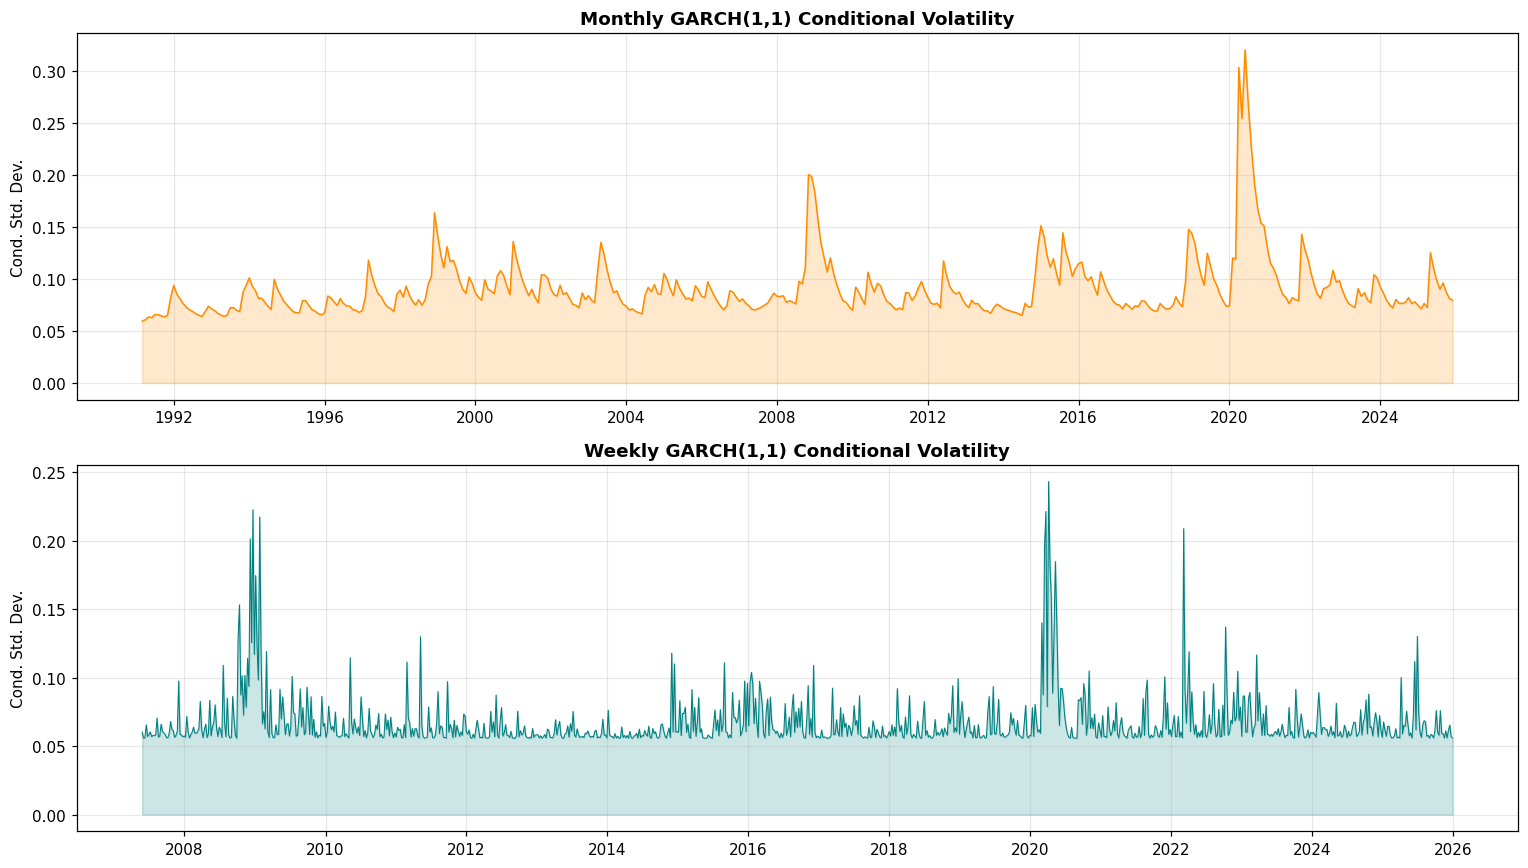

In [138]:
# ── Figure 7: Side-by-side conditional volatility ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

m_vol = garch_fit.conditional_volatility / 100
axes[0].plot(m_vol.index, m_vol, color="darkorange", linewidth=1)
axes[0].fill_between(m_vol.index, 0, m_vol, alpha=0.2, color="darkorange")
axes[0].set_title("Monthly GARCH(1,1) Conditional Volatility", weight="bold")
axes[0].set_ylabel("Cond. Std. Dev.")
axes[0].grid(True, alpha=0.3)

w_vol = w_garch_fit.conditional_volatility / 100
axes[1].plot(w_vol.index, w_vol, color="teal", linewidth=0.7)
axes[1].fill_between(w_vol.index, 0, w_vol, alpha=0.2, color="teal")
axes[1].set_title("Weekly GARCH(1,1) Conditional Volatility", weight="bold")
axes[1].set_ylabel("Cond. Std. Dev.")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Discussion & Conclusion

In [139]:
# ── Dynamic Conclusion Summary ──────────────────────────────────────────────
print("=" * 75)
print("SUMMARY OF FINDINGS")
print("=" * 75)

# Find overlapping predictors (strip _lag1 suffix for comparison)
m_base = {v.replace("_lag1", "") for v in sig_vars}
w_base = {v.replace("_lag1", "") for v in w_sig_vars}
shared = m_base & w_base
shared_str = ", ".join(shared) if shared else "none"

print(f"""
HYPOTHESIS: Can lagged macroeconomic and financial variables predict WTI
crude oil price changes? We tested this at monthly and weekly frequencies
over December 1990 – December 2025 using X(t-1) to predict WTI(t).

─── MONTHLY ANALYSIS ({len(reg_data)} observations) ───

1. OLS Multiple Regression (lagged predictors):
   - Adj. R² = {ols_reduced.rsquared_adj:.4f} — with lagged predictors, the model
     explains ~{ols_reduced.rsquared_adj*100:.1f}% of monthly WTI return variation.
   - This is much lower than a contemporaneous model would show, which is
     expected: most of the co-movement between WTI and other energy/financial
     variables is same-period, not predictable from last period.
   - Significant lagged predictors: {', '.join(v.replace('_lag1','') for v in sig_vars)}
   - Durbin-Watson = {dw:.4f} — no serial correlation.
   - Breusch-Pagan: heteroskedasticity detected → HAC standard errors reported.

2. ARCH-LM test on OLS residuals: p = {arch_p:.4f}
   → ARCH effects detected, GARCH estimation warranted.

3. Volatility Model: {best_name} selected by AIC.
   - Persistence (α+β+½γ) = {m_alpha + m_beta + 0.5*m_gamma:.4f}
   - Student-t df ≈ {garch_fit.params.get('nu', 0):.1f}

─── WEEKLY ANALYSIS ({len(w_reg_data)} observations) ───

1. OLS Multiple Regression (lagged predictors):
   - Adj. R² = {w_ols_red.rsquared_adj:.4f}
   - Significant lagged predictors: {', '.join(v.replace('_lag1','') for v in w_sig_vars)}
   - ARCH-LM: p = {w_arch_p:.4f} — strong ARCH effects.

2. Volatility Model: {w_best_name} selected by AIC.
   - Post-GARCH ARCH-LM: p = {w_arch_post[1]:.4f}

─── MONTHLY vs. WEEKLY COMPARISON ───

- Both models show low R² with lagged predictors — WTI returns are
  difficult to predict from prior-period information alone. This is
  consistent with semi-strong market efficiency in commodity markets.
- Predictors shared across both frequencies: {shared_str}
- ARCH effects are significant at BOTH frequencies with lagged
  regressors — volatility clustering is the dominant predictable feature.
- The GARCH variance equation captures this: volatility is persistent
  and partially forecastable even when returns themselves are not.

─── CONCLUSIONS ───

With lagged (t-1) predictors, the mean equation has limited predictive
power for WTI returns (R² ≈ {ols_reduced.rsquared_adj*100:.0f}% monthly, {w_ols_red.rsquared_adj*100:.0f}% weekly),
consistent with efficient-market theory. However, the variance equation
(GARCH) reveals that oil price VOLATILITY is predictable and persistent.
This has practical value: even if you cannot predict the direction of price
changes, you can forecast the magnitude of risk — which is exactly what
hedgers and risk managers need.

The key finding is the contrast between mean predictability (low) and
variance predictability (high). Supply-side fundamentals and treasury
yields provide some lagged predictive signal for returns, while the
GJR-GARCH structure captures the asymmetric, persistent nature of oil
price volatility.

─── FUTURE RESEARCH ───

- Additional lag structures (2, 3 periods) or VAR models
- Out-of-sample rolling-window volatility forecasting
- Structural break tests across regimes (2008, COVID)
- Regime-switching GARCH for crisis vs. calm periods
""")

SUMMARY OF FINDINGS

HYPOTHESIS: Can lagged macroeconomic and financial variables predict WTI
crude oil price changes? We tested this at monthly and weekly frequencies
over December 1990 – December 2025 using X(t-1) to predict WTI(t).

─── MONTHLY ANALYSIS (419 observations) ───

1. OLS Multiple Regression (lagged predictors):
   - Adj. R² = 0.0527 — with lagged predictors, the model
     explains ~5.3% of monthly WTI return variation.
   - This is much lower than a contemporaneous model would show, which is
     expected: most of the co-movement between WTI and other energy/financial
     variables is same-period, not predictable from last period.
   - Significant lagged predictors: indpro, tcmsy10_rate_diff
   - Durbin-Watson = 2.0026 — no serial correlation.
   - Breusch-Pagan: heteroskedasticity detected → HAC standard errors reported.

2. ARCH-LM test on OLS residuals: p = 0.0000
   → ARCH effects detected, GARCH estimation warranted.

3. Volatility Model: GJR-GARCH(1,1) selected 